In [3]:
import pyreadr
import pandas as pd
#from pandas.plotting import scatter_matrix
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, StandardScaler

from dfply import *



In [4]:

#a function to group the participants into high, middle and low responders
def response_category(df):
    """
    This function takes as input a dataframe that has columns named "pct_muscle_change"
    and "scaled_pct_change". It categorises participants as "High responder" if they
    belong to the upper 75% category in scaled percentage change; no_responder if they have pct_change_scores 0 0r below,
    average_responder if they are neither high nor no responders
    """
    if (df["scaled_pct_change"] >= 0.75):
        return "High_responder"
    if  (df["pct_muscle_change"] > 1 and df["scaled_pct_change"] < 0.75 ):
        return "Average_responder"
    if ( df["pct_muscle_change"] < 1):
        return "No_responder"
    
    

In [5]:

# A function that scales the percentage change based on volume and group of exercise
def scale_within_group(group):
    scaler = MinMaxScaler()
    group['scaled_pct_change'] = scaler.fit_transform(group[['pct_muscle_change']])
    return group


In [6]:

# A function to load the metadata of the different studies and the required columns
def process_metadata(filepath,  sequencing_depth):
    """
    Load and process COPD metadata from an RDS file.

    Parameters:
        filepath (str): Path to the RDS file.
        category_function (callable): Function to categorize participants based on muscle change.
        sequencing_depth (float or int): Value to assign as sequencing depth for all samples.

    Returns:
        pd.DataFrame: Processed COPD metadata.
    """
    # Load the RDS file
    data = pyreadr.read_r(filepath)[None]

    # Scale the percentage muscle change within each condition group and volume using the scale-within_group function
    data = (data.groupby(['condition', 'volume'], group_keys=False)
            .apply(scale_within_group)
            .reset_index(drop=True)
           )


    #Round to 2 decimal places
    data["scaled_pct_change"] = data["scaled_pct_change"].round(2)

    # Apply the categorization function
    data["category"] = data.apply(response_category, axis=1)

    # Add sequencing depth as a new column
    # This is calculated from the sequencing data
    data["sequencing_depth"] = sequencing_depth

    # Select relevant columns
    selected_columns = [
        "study", "participant", "sex", "seq_sample_id", "age", "BMI",
        "pct_muscle_change", "scaled_pct_change", "category", "volume",
        "condition", "sequencing_depth"
    ]
    return data[selected_columns]


In [7]:
copd_metadata = process_metadata("./COPD/copd_metadata.RDS", 1.2)
copd_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_6964\17582701.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(scale_within_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,scaled_pct_change,category,volume,condition,sequencing_depth
0,copd,FP102,female,X102PreExcVLR12,65.8,36.6,-1.98,0.38,No_responder,3.0,RM30,1.2
1,copd,FP102,female,X102PreExcVLR12,65.8,36.6,17.24,0.79,High_responder,3.0,RM10,1.2
2,copd,FP103,male,X103PreExcVLR23,70.9,28.5,6.81,0.45,Average_responder,3.0,RM10,1.2
3,copd,FP103,male,X103PreExcVLR23,70.9,28.5,14.01,0.81,High_responder,3.0,RM30,1.2
4,copd,FP105,female,X105PreExcVLR38,67.0,24.6,13.87,0.80,High_responder,3.0,RM30,1.2
...,...,...,...,...,...,...,...,...,...,...,...,...
98,copd,FP246,female,X246PreExcVLR518,64.3,22.4,6.10,0.43,Average_responder,3.0,RM10,1.2
99,copd,FP246,female,X246PreExcVLL519,64.3,22.4,3.88,0.54,Average_responder,3.0,RM30,1.2
100,copd,FP249,male,X249PreExcVLL529,63.6,22.0,4.32,0.55,Average_responder,3.0,RM30,1.2
101,copd,FP249,male,X249PreExcVLL529,63.6,22.0,3.34,0.34,Average_responder,3.0,RM10,1.2


In [48]:
np.percentile(copd_metadata["pct_muscle_change"], 95)

18.53099999999999

Text(0.5, 1.0, 'Percentage muscle change among COPD participants')

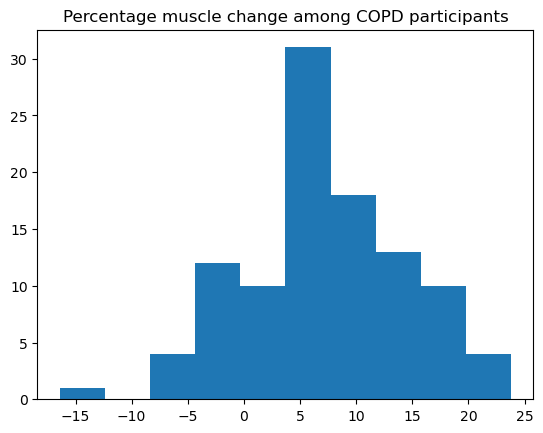

In [9]:
plt.hist(copd_metadata["pct_muscle_change"])
plt.title("Percentage muscle change among COPD participants")

In [10]:
copd_metadata["participant"].nunique()

53

In [11]:
copd_metadata["age"].max()

79.0

In [12]:
copd_metadata["age"].min()

56.7

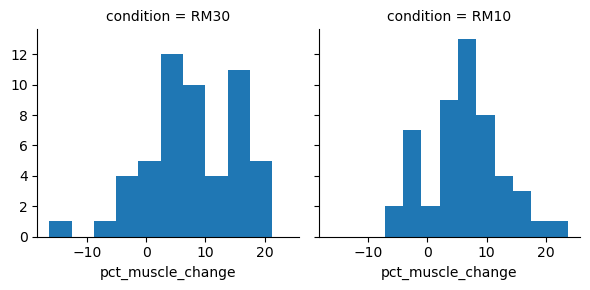

In [13]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(copd_metadata, col = "condition")
g.map(plt.hist, "pct_muscle_change")

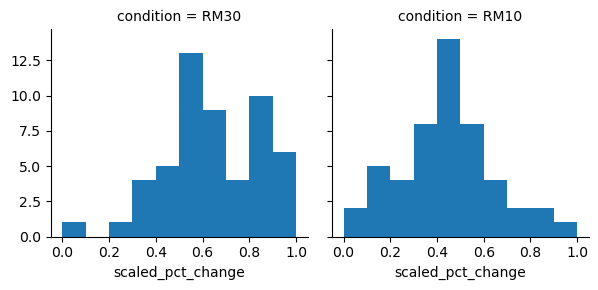

In [14]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(copd_metadata, col = "condition")
g.map(plt.hist, "scaled_pct_change")

In [15]:
contratrain_metadata = process_metadata("./ContraTrain/Contratrain_metadata.RDS", 4.03)

contratrain_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_6964\17582701.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(scale_within_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,scaled_pct_change,category,volume,condition,sequencing_depth
0,ct,FP1,female,X1.subj1sample1,21.0,28.6,3.78,0.57,Average_responder,0.0,RM10,4.03
1,ct,FP1,female,X2.subj1sample6,21.0,28.6,12.98,0.71,Average_responder,3.0,RM10,4.03
2,ct,FP2,male,X43.subj2sample4,24.0,31.2,9.88,0.60,Average_responder,3.0,RM10,4.03
3,ct,FP2,male,X44.subj2sample6,24.0,31.2,9.23,0.21,Average_responder,6.0,RM10,4.03
4,ct,FP3,female,X75.subj3sample5,23.0,22.5,17.03,0.40,Average_responder,6.0,RM10,4.03
...,...,...,...,...,...,...,...,...,...,...,...,...
59,ct,FP43,female,X108.subj43sample3,24.0,40.1,-1.62,0.29,No_responder,0.0,RM10,4.03
60,ct,FP44,female,X113.subj44sample4,30.0,24.6,10.30,0.62,Average_responder,3.0,RM10,4.03
61,ct,FP45,female,X116.subj45sample4,20.0,26.2,2.46,0.33,Average_responder,3.0,RM10,4.03
62,ct,FP46,female,X121.subj46sample7,22.0,22.9,3.90,0.57,Average_responder,0.0,RM10,4.03


In [49]:
np.percentile(contratrain_metadata["pct_muscle_change"], 95)

22.135999999999992

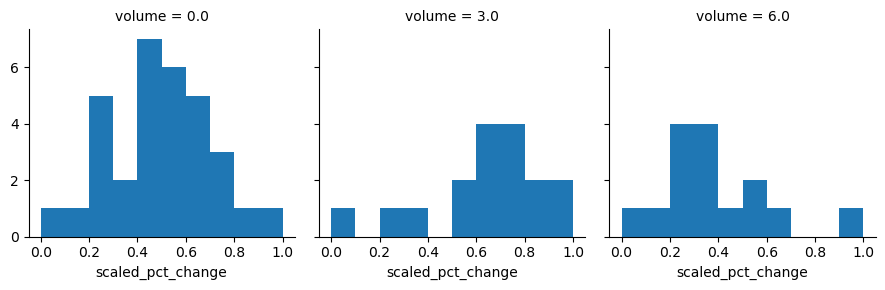

In [16]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(contratrain_metadata, col = "volume")
g.map(plt.hist, "scaled_pct_change")

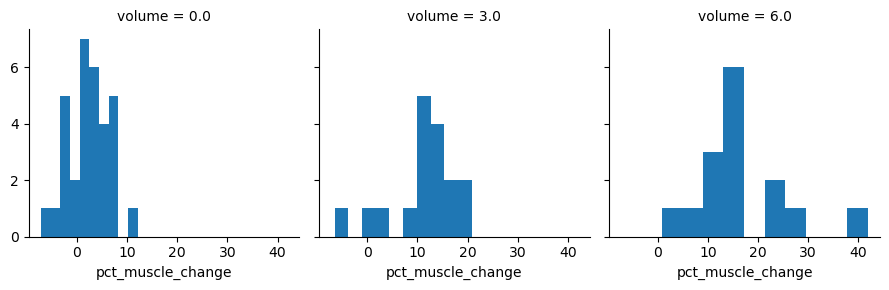

In [17]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(contratrain_metadata, col = "volume")
g.map(plt.hist, "pct_muscle_change")

In [18]:
contratrain_metadata["participant"].nunique()

32

In [19]:
contratrain_metadata["age"].max()

35.0

In [20]:
contratrain_metadata["age"].min()

19.0

In [21]:
AO_metadata = process_metadata("./Alpha_Omega/Alpha_Omega_metadata.RDS", 2.35)
AO_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_6964\17582701.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(scale_within_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,scaled_pct_change,category,volume,condition,sequencing_depth
0,Alpha/Omega,516,male,s104,46.0,29.0,18.75,0.46,Average_responder,3.0,RM10,2.35
1,Alpha/Omega,517,male,s112,53.0,30.3,12.66,0.36,Average_responder,3.0,RM10,2.35
2,Alpha/Omega,503,male,s13,46.0,25.3,50.37,1.00,High_responder,3.0,RM10,2.35
3,Alpha/Omega,520,male,s130,58.0,29.9,8.62,0.29,Average_responder,3.0,RM10,2.35
4,Alpha/Omega,521,female,s136,48.0,18.4,33.69,0.72,Average_responder,3.0,RM10,2.35
...,...,...,...,...,...,...,...,...,...,...,...,...
161,Alpha/Omega,683,female,s874,35.0,29.3,2.60,0.10,Average_responder,3.0,RM30,2.35
162,Alpha/Omega,684,female,s875,48.0,31.6,24.79,0.47,Average_responder,3.0,RM30,2.35
163,Alpha/Omega,692,male,s883,58.0,23.9,43.34,0.79,High_responder,3.0,RM30,2.35
164,Alpha/Omega,693,female,s891,54.0,21.8,21.82,0.42,Average_responder,3.0,RM30,2.35


In [50]:
np.percentile(AO_metadata["pct_muscle_change"], 95)

34.64

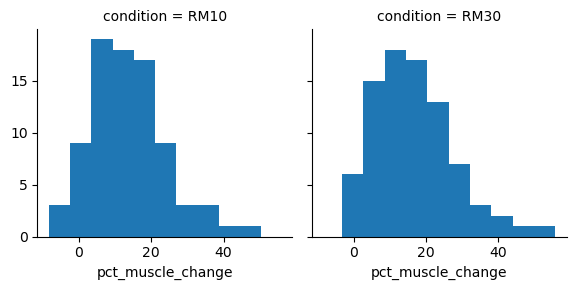

In [22]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(AO_metadata, col = "condition")
g.map(plt.hist, "pct_muscle_change")

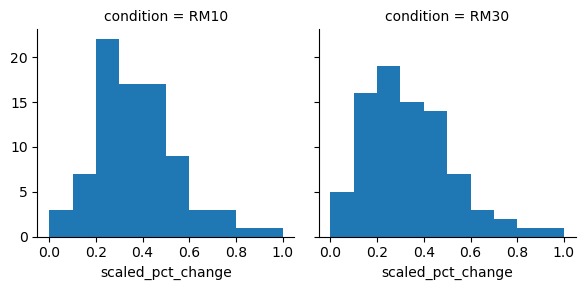

In [23]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(AO_metadata, col = "condition")
g.map(plt.hist, "scaled_pct_change")

In [24]:
AO_metadata["participant"].nunique()

83

In [25]:
AO_metadata["age"].max()

60.0

In [26]:
AO_metadata["age"].min()

31.0

Text(0.5, 1.0, 'Percentage muscle change among AO participants')

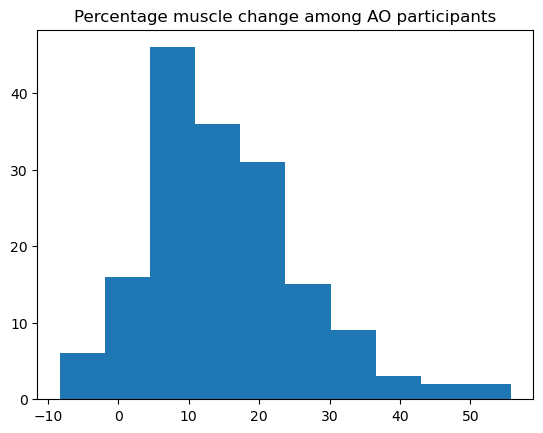

In [27]:
plt.hist(AO_metadata["pct_muscle_change"])
plt.title("Percentage muscle change among AO participants")

(array([ 8., 23., 41., 32., 31., 16.,  6.,  5.,  2.,  2.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

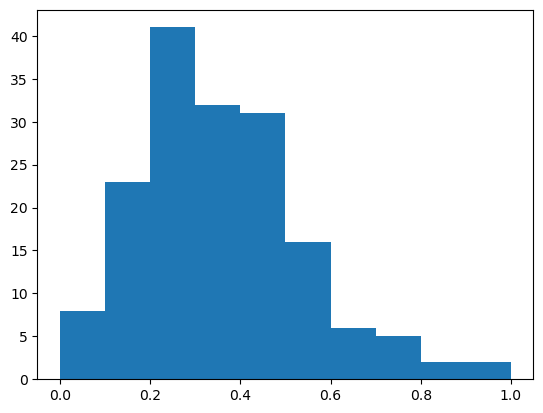

In [28]:
plt.hist(AO_metadata["scaled_pct_change"])

<Axes: xlabel='category', ylabel='count'>

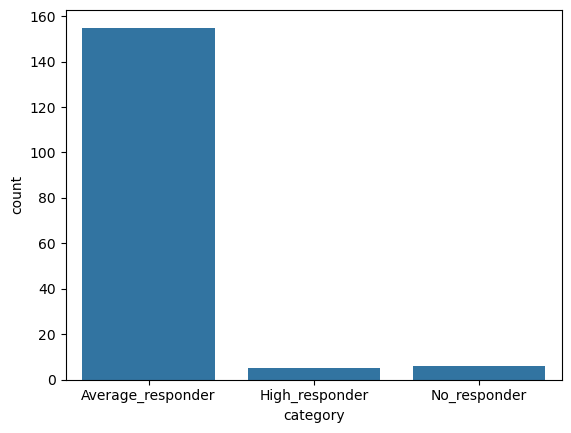

In [29]:
sns.countplot(x =AO_metadata["category"])

In [30]:
Volume_metadata = process_metadata("./Volume/Volume_metadata.RDS", 1.51)
Volume_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_6964\17582701.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(scale_within_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,scaled_pct_change,category,volume,condition,sequencing_depth
0,vol,FP11,male,FP11w0R,22.3,23.6,0.18,0.07,Average_responder,3.0,RM10,1.51
1,vol,FP11,male,FP11w0L,22.3,23.6,-1.53,0.05,No_responder,1.0,RM10,1.51
2,vol,FP12,female,FP12w0R,21.3,22.8,-0.60,0.01,No_responder,3.0,RM10,1.51
3,vol,FP12,female,FP12w0L,21.3,22.8,0.68,0.21,Average_responder,1.0,RM10,1.51
4,vol,FP13,male,FP13w0L,22.7,19.8,12.12,0.99,High_responder,3.0,RM10,1.51
5,vol,FP13,male,FP13w0R,22.7,19.8,6.72,0.66,Average_responder,1.0,RM10,1.51
6,vol,FP14,female,FP14w0R,22.1,24.1,6.45,0.55,Average_responder,3.0,RM10,1.51
7,vol,FP14,female,FP14w0L,22.1,24.1,6.16,0.62,Average_responder,1.0,RM10,1.51
8,vol,FP15,male,FP15w0R,23.6,21.1,5.26,0.46,Average_responder,3.0,RM10,1.51
9,vol,FP15,male,FP15w0L,23.6,21.1,2.68,0.36,Average_responder,1.0,RM10,1.51


In [31]:
Volume_metadata["participant"].nunique()

25

In [32]:
Volume_metadata["age"].max()

37.4

In [33]:
Volume_metadata["age"].min()

20.5

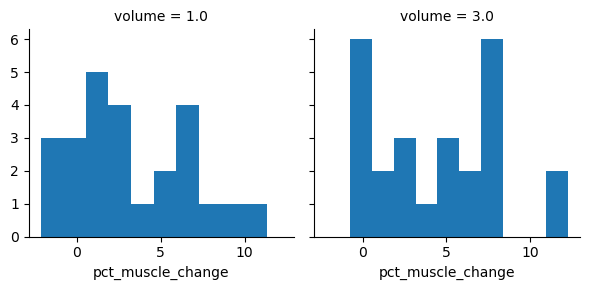

In [34]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(Volume_metadata, col = "volume")
g.map(plt.hist, "pct_muscle_change")

Text(0.5, 1.0, 'Percentage muscle change among Vol participants')

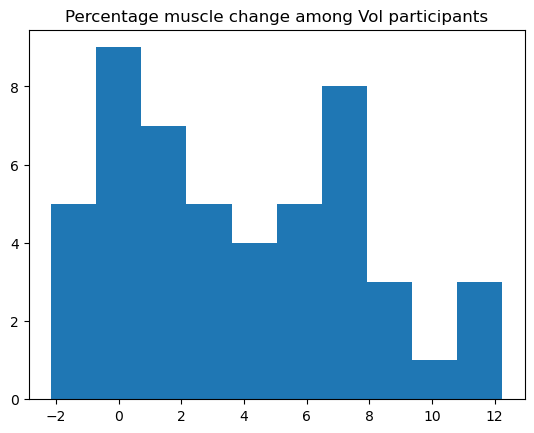

In [35]:
plt.hist(Volume_metadata["pct_muscle_change"])
plt.title("Percentage muscle change among Vol participants")

(array([ 9.,  4., 10.,  3.,  5.,  4., 10.,  1.,  1.,  3.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

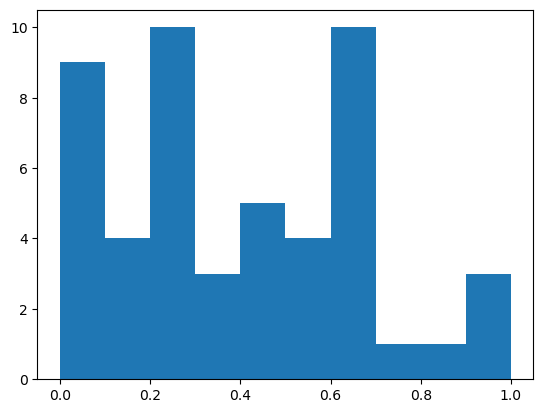

In [36]:
plt.hist(Volume_metadata["scaled_pct_change"])

<Axes: xlabel='category', ylabel='count'>

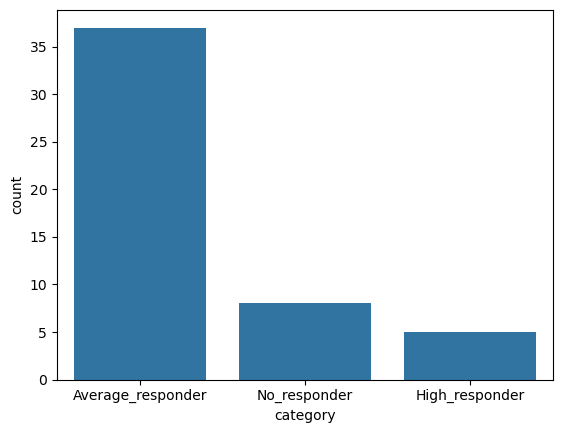

In [37]:
sns.countplot(x = Volume_metadata["category"])

In [38]:
Relief_metadata = process_metadata("./Relief/Relief_metadata.RDS", 2.33)
Relief_metadata

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_6964\17582701.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(scale_within_group)


,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,scaled_pct_change,category,volume,condition,sequencing_depth
0,ReLiEf,3003,male,R_8,27.0,25.9,33.45,0.88,High_responder,1.0,RM10,2.33
1,ReLiEf,3006,male,R_18,21.0,24.5,4.39,0.42,Average_responder,1.0,RM10,2.33
2,ReLiEf,3007,male,R_25,73.0,24.2,-16.01,0.09,No_responder,1.0,RM10,2.33
3,ReLiEf,3009,male,R_30,79.0,26.0,33.09,0.66,Average_responder,3.0,RM10,2.33
4,ReLiEf,3009,male,R_34,79.0,26.0,3.29,0.40,Average_responder,1.0,RM10,2.33
...,...,...,...,...,...,...,...,...,...,...,...,...
73,ReLiEf,3075,male,R_321,81.0,22.6,8.58,0.35,Average_responder,3.0,RM10,2.33
74,ReLiEf,3079,male,R_331,23.0,28.7,23.89,0.54,Average_responder,3.0,RM10,2.33
75,ReLiEf,3083,male,R_342,72.0,29.4,18.51,0.64,Average_responder,1.0,RM10,2.33
76,ReLiEf,3084,male,R_348,80.0,20.2,-6.90,0.14,No_responder,3.0,RM10,2.33


In [39]:
Relief_metadata["participant"].nunique()

39

In [40]:
Relief_metadata["age"].max()

86.0

In [41]:
Relief_metadata["age"].min()

20.0

Text(0.5, 1.0, 'Percentage muscle change among Relief participants')

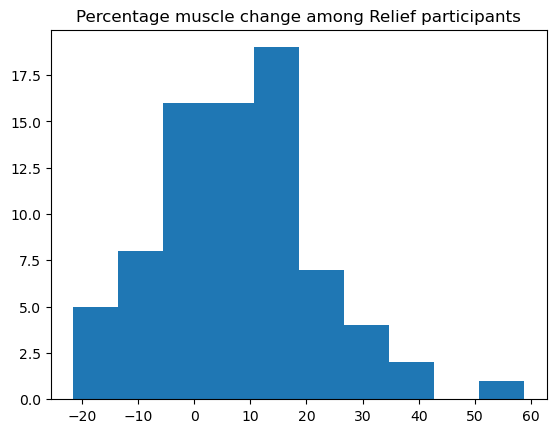

In [42]:
plt.hist(Relief_metadata["pct_muscle_change"])
plt.title("Percentage muscle change among Relief participants")

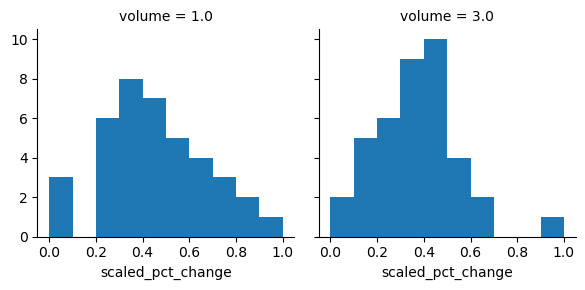

In [43]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(Relief_metadata, col = "volume")
g.map(plt.hist, "scaled_pct_change")

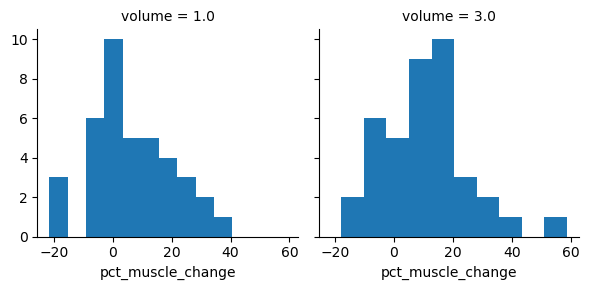

In [44]:
# Create a faceted histogram of the percentage muscle change by condition
g = sns.FacetGrid(Relief_metadata, col = "volume")
g.map(plt.hist, "pct_muscle_change")

<Axes: xlabel='category', ylabel='count'>

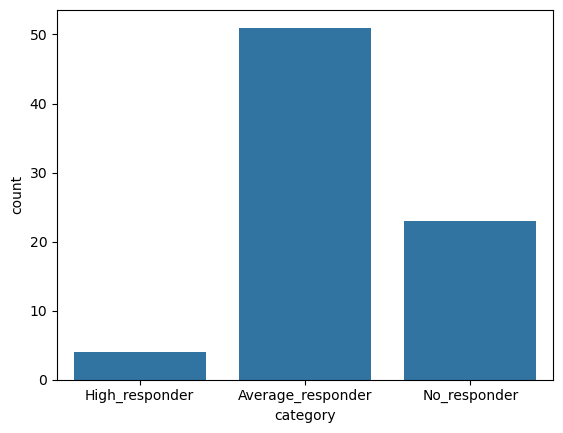

In [45]:
sns.countplot(x = Relief_metadata["category"])

In [46]:
# Concatenate dataset into one
full_metadata = pd.concat([AO_metadata, contratrain_metadata, copd_metadata,Relief_metadata, Volume_metadata], ignore_index = True)
# distinguish each participant from the other in different studies
full_metadata["participant"] = full_metadata["study"] + "_" + full_metadata["participant"]
# ensure volume is integer
full_metadata["volume"] = full_metadata["volume"].astype(int)
full_metadata

,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,scaled_pct_change,category,volume,condition,sequencing_depth
0,Alpha/Omega,Alpha/Omega_516,male,s104,46.0,29.0,18.75,0.46,Average_responder,3,RM10,2.35
1,Alpha/Omega,Alpha/Omega_517,male,s112,53.0,30.3,12.66,0.36,Average_responder,3,RM10,2.35
2,Alpha/Omega,Alpha/Omega_503,male,s13,46.0,25.3,50.37,1.00,High_responder,3,RM10,2.35
3,Alpha/Omega,Alpha/Omega_520,male,s130,58.0,29.9,8.62,0.29,Average_responder,3,RM10,2.35
4,Alpha/Omega,Alpha/Omega_521,female,s136,48.0,18.4,33.69,0.72,Average_responder,3,RM10,2.35
...,...,...,...,...,...,...,...,...,...,...,...,...
456,vol,vol_FP6,female,FP6w0R,21.8,20.5,-0.81,0.10,No_responder,1,RM10,1.51
457,vol,vol_FP7,male,FP7w0L,21.2,28.2,8.34,0.70,Average_responder,3,RM10,1.51
458,vol,vol_FP7,male,FP7w0R,21.2,28.2,11.31,1.00,High_responder,1,RM10,1.51
459,vol,vol_FP9,male,FP9w0R,20.6,21.2,7.17,0.61,Average_responder,3,RM10,1.51


Text(0.5, 1.0, 'Percentage muscle change among all participants')

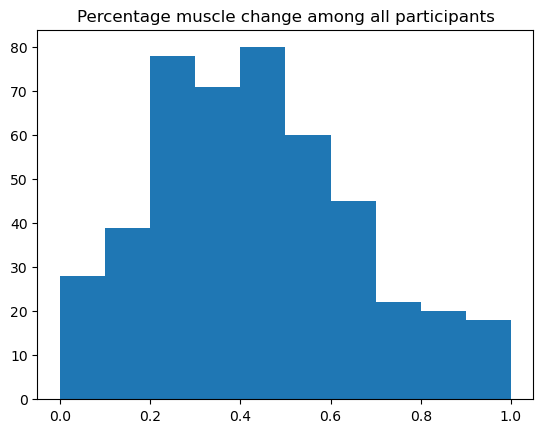

In [27]:
plt.hist(full_metadata["scaled_pct_change"])
plt.title("Percentage muscle change among all participants")

<Axes: xlabel='category', ylabel='count'>

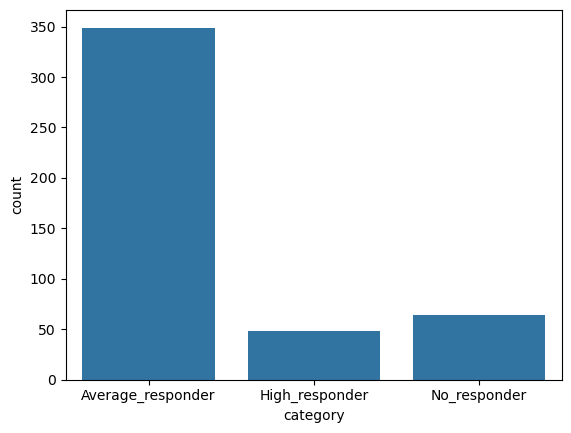

In [28]:
sns.countplot(x = full_metadata["category"])

In [29]:
# concatenate all metadata except volume. This is to check the effect of muscle measurement tool

metadata = pd.concat([AO_metadata, contratrain_metadata, copd_metadata,Relief_metadata], ignore_index = True)
# distinguish each participant from the other in studies
metadata["participant"] = metadata["study"] + "_" + metadata["participant"]
metadata["volume"] = metadata["volume"].astype(int)
metadata

,study,participant,sex,seq_sample_id,age,BMI,pct_muscle_change,scaled_pct_change,category,volume,condition,sequencing_depth
0,Alpha/Omega,Alpha/Omega_516,male,s104,46.0,29.0,18.75,0.46,Average_responder,3,RM10,2.35
1,Alpha/Omega,Alpha/Omega_517,male,s112,53.0,30.3,12.66,0.36,Average_responder,3,RM10,2.35
2,Alpha/Omega,Alpha/Omega_503,male,s13,46.0,25.3,50.37,1.00,High_responder,3,RM10,2.35
3,Alpha/Omega,Alpha/Omega_520,male,s130,58.0,29.9,8.62,0.29,Average_responder,3,RM10,2.35
4,Alpha/Omega,Alpha/Omega_521,female,s136,48.0,18.4,33.69,0.72,Average_responder,3,RM10,2.35
...,...,...,...,...,...,...,...,...,...,...,...,...
406,ReLiEf,ReLiEf_3075,male,R_321,81.0,22.6,8.58,0.35,Average_responder,3,RM10,2.33
407,ReLiEf,ReLiEf_3079,male,R_331,23.0,28.7,23.89,0.54,Average_responder,3,RM10,2.33
408,ReLiEf,ReLiEf_3083,male,R_342,72.0,29.4,18.51,0.64,Average_responder,1,RM10,2.33
409,ReLiEf,ReLiEf_3084,male,R_348,80.0,20.2,-6.90,0.14,No_responder,3,RM10,2.33


In [30]:
full_metadata.to_csv("./full_metadata.csv", index= False)

# save the one without Volume metadata
metadata.to_csv("./metadata_excluding_volume.csv", index = False)

Load the gene expression data of the 5 datasets. These contain the normalised (CPM) values of the data. The data will be first scaled individually, then the combined dataset will be scaled together. This would allows amintaining the individual characteristics of each dataset while ensuring consistency across the combined dataset

In [28]:
# AOData
AO_genecounts = pyreadr.read_r("./gene_extracts/cpm_normalised_PreExc_AO_counts.RDS")
AO_genecounts = AO_genecounts[None]

# scale the values

transformer = FunctionTransformer(np.log1p, validate=True)
AO_transformed = transformer.transform(AO_genecounts.iloc[:, 1:])
AO_transformed = pd.DataFrame(AO_transformed, columns = AO_genecounts.columns[1:])

# Initialise the scaler
scaler2 = StandardScaler()
# scale
AO_scaled = scaler2.fit_transform(AO_transformed)
AO_scaled = pd.DataFrame(AO_scaled, columns = AO_genecounts.columns[1:])

AO_scaled.insert(0, 'gene_id', AO_genecounts['gene_id'])
AO_scaled = AO_scaled.round(2)
AO_scaled


C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


,gene_id,s104,s112,s13,s130,s136,s147,s153,s159,s170,...,s822,s828,s859,s874,s875,s883,s89,s891,s903,s96
0,ENSG00000000003.16,-0.91,-0.68,-1.00,-1.02,-0.77,-1.03,-0.74,-0.69,-0.88,...,-0.55,-0.84,-0.78,-0.65,-0.76,-0.62,-0.75,-0.74,-0.67,-0.62
1,ENSG00000000419.14,0.32,0.33,0.28,0.21,0.35,0.34,0.18,0.38,0.32,...,0.20,0.26,0.20,0.31,0.21,0.47,0.29,0.30,0.29,0.51
2,ENSG00000000457.14,-0.46,-0.43,-0.50,-0.26,-0.36,-0.41,-0.46,-0.32,-0.33,...,-0.32,-0.32,-0.34,-0.32,-0.23,-0.18,-0.31,-0.38,-0.30,-0.31
3,ENSG00000000971.17,0.04,0.31,-0.01,0.14,0.25,0.32,-0.02,0.18,0.14,...,0.21,0.09,0.81,0.04,-0.08,-0.03,-0.09,-0.12,0.16,0.05
4,ENSG00000001036.14,-0.69,-0.50,-0.64,-0.87,-0.51,-0.55,-0.56,-0.70,-0.56,...,-0.57,-0.60,-0.58,-0.80,-0.62,-0.80,-0.81,-0.66,-0.61,-0.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13408,ENSG00000310523.1,0.07,0.02,0.33,0.44,-0.01,0.13,0.38,-0.02,0.13,...,0.30,0.06,0.47,0.26,0.47,0.34,0.11,0.26,0.07,0.17
13409,ENSG00000310526.1,0.18,0.63,0.68,0.67,0.25,0.45,0.69,0.17,0.55,...,0.63,0.38,0.52,0.52,0.40,0.43,0.30,0.61,0.56,0.46
13410,ENSG00000310527.1,0.20,0.46,0.67,0.60,0.20,0.41,0.45,0.42,0.11,...,0.31,0.03,0.26,0.20,-0.02,0.34,0.12,0.58,0.28,0.56
13411,ENSG00000310533.1,-1.03,-0.83,-0.95,-0.94,-0.79,-1.06,-0.79,-1.15,-1.37,...,-0.96,-0.43,-0.94,-1.24,-0.95,-0.67,-1.05,-0.74,-1.33,-0.84


In [29]:
# Contratrain
Contratrain_genecounts = pyreadr.read_r("./gene_extracts/cpm_normalised_PreExc_contratrain_counts.RDS")
Contratrain_genecounts = Contratrain_genecounts[None]

# scale the values

Contratrain_transformed = transformer.transform(Contratrain_genecounts.iloc[:, 1:])
Contratrain_transformed = pd.DataFrame(Contratrain_transformed, columns = Contratrain_genecounts.columns[1:])


# scale
Contratrain_scaled = scaler2.fit_transform(Contratrain_transformed)
Contratrain_scaled = pd.DataFrame(Contratrain_scaled, columns = Contratrain_genecounts.columns[1:])

Contratrain_scaled.insert(0, 'gene_id', Contratrain_genecounts['gene_id'])
Contratrain_scaled = Contratrain_scaled.round(2)
Contratrain_scaled

C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


,gene_id,X1.subj1sample1,X2.subj1sample6,X43.subj2sample4,X44.subj2sample6,X75.subj3sample5,X93.subj4sample5,X125.subj5sample4,X130.subj6sample6,X134.subj8sample4,...,X72.subj29sample6,X80.subj30sample4,X83.subj31sample5,X98.subj40sample7,X103.subj41sample2,X108.subj43sample3,X113.subj44sample4,X116.subj45sample4,X121.subj46sample7,X123.subj47sample2
0,ENSG00000000003.16,-0.31,-0.26,-0.55,-0.40,-0.66,-0.45,-0.44,-0.32,-0.50,...,-0.62,-0.45,-0.74,-0.48,-0.52,-0.56,-0.45,-0.39,-0.64,-0.53
1,ENSG00000000419.14,0.87,0.78,0.76,0.79,0.67,0.81,0.75,0.72,0.63,...,0.65,0.78,0.57,0.80,0.72,0.80,0.60,0.46,0.65,0.65
2,ENSG00000000457.14,-0.10,-0.32,-0.17,-0.18,-0.25,0.04,-0.13,-0.16,-0.15,...,-0.27,-0.09,-0.50,-0.22,-0.14,-0.26,-0.10,-0.07,-0.22,-0.26
3,ENSG00000000460.17,-1.20,-1.28,-1.14,-1.45,-1.32,-1.19,-1.28,-1.14,-1.51,...,-1.28,-1.36,-1.31,-1.28,-1.15,-1.09,-1.38,-1.08,-1.24,-1.47
4,ENSG00000000971.17,0.40,0.44,0.51,0.37,0.32,0.68,0.66,0.19,0.33,...,0.68,0.50,0.24,0.57,0.60,0.46,0.22,0.91,0.55,0.44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13774,ENSG00000310523.1,-0.32,-0.29,-0.23,-0.23,-0.22,-0.50,-0.33,-0.42,-0.44,...,-0.35,-0.52,0.14,-0.33,-0.36,-0.58,-0.32,-0.54,-0.19,0.01
13775,ENSG00000310526.1,-0.06,0.24,0.13,0.23,0.35,-0.35,-0.03,-0.23,0.02,...,-0.05,-0.12,0.05,0.04,0.09,-0.39,0.03,-0.60,0.08,0.60
13776,ENSG00000310527.1,-0.39,-0.43,-0.12,0.02,0.19,-0.66,-0.51,-0.37,0.00,...,-0.46,-0.34,0.34,-0.13,-0.11,-0.63,-0.26,-0.70,-0.15,0.21
13777,ENSG00000310533.1,-0.88,-0.95,-1.01,-0.65,-1.05,-0.77,-0.77,-0.81,-0.67,...,-0.83,-0.98,-1.55,-0.83,-0.72,-0.85,-0.66,-0.63,-0.65,-0.51


In [30]:
# Copd
Copd_genecounts = pyreadr.read_r("./gene_extracts/cpm_normalised_PreExc_COPD_counts.RDS")
Copd_genecounts = Copd_genecounts[None]

# scale the values
Copd_transformed = transformer.transform(Copd_genecounts.iloc[:, 1:])
Copd_transformed = pd.DataFrame(Copd_transformed, columns = Copd_genecounts.columns[1:])


# scale
Copd_scaled = scaler2.fit_transform(Copd_transformed)
Copd_scaled = pd.DataFrame(Copd_scaled, columns = Copd_genecounts.columns[1:])

Copd_scaled.insert(0, 'gene_id', Copd_genecounts['gene_id'])
Copd_scaled = Copd_scaled.round(2)
Copd_scaled

C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


,gene_id,X102PreExcVLR12,X103PreExcVLR23,X105PreExcVLR38,X106PreExcVLR43,X110PreExcVLL58,X111PreExcVLL67,X111PreExcVLR69,X113PreExcVLL72,X113PreExcVLR74,...,X238PreExcVLL489,X239PreExcVLR496,X242PreExcVLR501,X242PreExcVLL506,X243PreExcVLL509,X243PreExcVLR510,X246PreExcVLR518,X246PreExcVLL519,X249PreExcVLL529,X250PreExcVLR538
0,ENSG00000000003.16,-0.75,-0.99,-0.92,-0.71,-0.92,-0.89,-0.73,-0.89,-0.95,...,-0.90,-1.06,-0.81,-1.13,-0.66,-1.02,-0.85,-0.69,-0.98,-0.71
1,ENSG00000000419.14,0.78,0.79,0.59,0.43,0.43,0.45,0.48,0.48,0.47,...,0.52,0.43,0.77,0.70,0.54,0.46,0.44,0.41,0.49,0.60
2,ENSG00000000457.14,-0.47,-0.27,-0.55,-0.46,-0.43,-0.66,-0.63,-0.46,-0.44,...,-0.52,-0.54,-0.70,-0.46,-0.28,-0.34,-0.40,-0.66,-0.47,-0.31
3,ENSG00000000971.17,0.39,0.44,0.45,0.47,0.29,0.57,0.85,0.41,0.37,...,0.59,0.28,0.66,-0.13,0.66,0.76,0.40,0.53,0.46,0.41
4,ENSG00000001036.14,-0.60,-0.54,-0.42,-0.78,-0.92,-0.49,-0.36,-0.86,-0.66,...,-0.75,-0.83,-0.74,-1.13,-0.66,-0.62,-0.72,-0.93,-1.11,-0.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11313,ENSG00000310517.1,1.90,1.99,1.86,1.71,1.86,1.96,1.94,1.84,1.71,...,1.83,1.76,1.80,1.74,1.85,1.68,1.87,1.85,1.99,1.83
11314,ENSG00000310523.1,-0.98,-1.12,-0.97,-0.55,-0.55,-0.93,-0.55,-0.66,-0.63,...,-0.59,-0.65,-0.68,-0.49,-0.71,-0.81,-0.39,-0.95,-0.81,-0.72
11315,ENSG00000310526.1,-0.88,-0.37,-0.63,-0.16,-0.50,-0.11,-0.05,-0.65,-0.45,...,-0.69,-0.52,-0.47,-0.20,-0.75,-0.34,-0.43,-0.48,-0.31,-0.54
11316,ENSG00000310527.1,-0.75,-0.99,-0.94,-0.71,-0.70,-0.37,-0.53,-0.47,-0.40,...,-0.85,-0.97,-0.48,-0.05,-1.04,-1.09,-0.60,-0.54,-0.71,-0.31


In [31]:
# Relief
Relief_genecounts = pyreadr.read_r("./gene_extracts/cpm_normalised_PreExc_Relief_counts.RDS")
Relief_genecounts = Relief_genecounts[None]

# scale the values
Relief_transformed = transformer.transform(Relief_genecounts.iloc[:, 1:])
Relief_transformed = pd.DataFrame(Relief_transformed, columns = Relief_genecounts.columns[1:])


# scale
Relief_scaled = scaler2.fit_transform(Relief_transformed)
Relief_scaled = pd.DataFrame(Relief_scaled, columns = Relief_genecounts.columns[1:])

Relief_scaled.insert(0, 'gene_id', Relief_genecounts['gene_id'])
Relief_scaled = Relief_scaled.round(2)
Relief_scaled

C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


,gene_id,R_8,R_18,R_25,R_30,R_34,R_40,R_42,R_48,R_53,...,R_272,R_301,R_316,R_321,R_331,R_342,R_348,R_352,R_353,R_358
0,ENSG00000000003.16,-0.83,-0.59,-0.90,-0.86,-0.97,-0.78,-0.87,-0.67,-0.73,...,-0.49,-0.59,-0.33,-0.41,-0.74,-0.64,-0.52,-0.72,-0.69,-0.65
1,ENSG00000000419.14,0.15,0.27,0.28,0.24,0.33,0.02,0.15,0.25,0.22,...,0.50,0.43,0.41,0.32,0.38,0.29,0.43,0.35,0.32,0.39
2,ENSG00000000457.14,-0.29,-0.42,-0.48,-0.62,-0.66,-0.43,-0.27,-0.42,-0.34,...,-0.08,-0.24,-0.19,-0.20,-0.42,-0.20,-0.22,-0.06,-0.20,-0.08
3,ENSG00000000460.17,-1.63,-1.45,-1.48,-1.84,-1.56,-1.63,-1.67,-1.57,-1.34,...,-1.63,-1.12,-1.60,-1.46,-1.55,-1.80,-1.39,-1.36,-1.09,-1.16
4,ENSG00000000971.17,-0.30,-0.24,-0.04,0.25,0.22,-0.14,-0.04,0.20,-0.16,...,0.46,0.30,0.90,0.66,0.68,0.45,0.38,0.39,0.49,0.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13227,ENSG00000310517.1,1.84,1.74,1.75,1.64,1.70,1.81,1.70,1.61,1.74,...,2.18,2.08,2.09,2.24,2.45,2.19,2.08,2.06,2.00,2.06
13228,ENSG00000310523.1,0.18,0.38,0.34,0.35,0.16,0.43,0.33,0.25,0.32,...,-0.27,-0.20,0.04,-0.18,-0.08,-0.18,-0.03,0.09,-0.03,-0.37
13229,ENSG00000310526.1,0.32,0.58,0.46,0.51,0.62,0.63,0.19,0.63,0.34,...,0.10,0.31,0.34,0.08,0.20,-0.27,0.11,0.31,0.29,0.37
13230,ENSG00000310527.1,0.10,0.40,0.57,0.41,0.46,0.43,0.34,0.55,0.40,...,-0.36,0.05,0.14,-0.35,0.09,-0.27,-0.32,-0.07,-0.19,0.03


In [32]:
# Volume
Volume_genecounts = pyreadr.read_r("./gene_extracts/cpm_normalised_PreExc_vol_counts.RDS")
Volume_genecounts = Volume_genecounts[None]

# scale the values
Volume_transformed = transformer.transform(Volume_genecounts.iloc[:, 1:])
Volume_transformed = pd.DataFrame(Volume_transformed, columns = Volume_genecounts.columns[1:])


# scale
Volume_scaled = scaler2.fit_transform(Volume_transformed)
Volume_scaled = pd.DataFrame(Volume_scaled, columns = Volume_genecounts.columns[1:])

Volume_scaled.insert(0, 'gene_id', Volume_genecounts['gene_id'])
Volume_scaled = Volume_scaled.round(2)
Volume_scaled

C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but FunctionTransformer was fitted without feature names
  warnings.warn(


,gene_id,FP11w0R,FP11w0L,FP12w0R,FP12w0L,FP13w0L,FP13w0R,FP14w0R,FP14w0L,FP15w0R,...,FP46w0R,FP46w0L,FP5w0R,FP5w0L,FP6w0L,FP6w0R,FP7w0L,FP7w0R,FP9w0R,FP9w0L
0,ENSG00000000003.16,-0.74,-0.85,-0.63,-0.67,-0.66,-0.75,-0.84,-0.89,-0.79,...,-0.58,-1.13,-0.65,-0.65,-0.67,-0.52,-0.87,-0.78,-0.85,-0.75
1,ENSG00000000419.14,0.50,0.56,0.49,0.60,0.61,0.46,0.62,0.47,0.66,...,0.72,0.73,0.60,0.78,0.58,0.59,0.65,0.64,0.63,0.60
2,ENSG00000000457.14,-0.27,-0.35,-0.65,-0.58,-0.76,-0.39,-0.66,-0.55,-0.61,...,-0.27,-0.61,-0.47,-0.41,-0.53,-0.35,-0.45,-0.62,-0.42,-0.36
3,ENSG00000000971.17,0.23,0.07,0.08,0.04,-0.33,-0.14,0.64,0.63,-0.13,...,0.03,0.21,0.14,0.02,0.07,0.35,0.16,0.20,-0.14,-0.04
4,ENSG00000001036.14,-0.58,-0.94,-1.04,-1.02,-1.16,-0.98,-0.55,-0.79,-0.98,...,-0.88,-0.80,-0.84,-0.67,-0.77,-0.72,-0.87,-0.89,-0.76,-0.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11358,ENSG00000310517.1,2.15,2.08,1.71,1.73,1.75,1.80,1.87,1.94,1.65,...,1.75,1.75,1.89,1.95,1.71,1.76,1.79,1.80,1.89,1.86
11359,ENSG00000310523.1,-0.60,-0.58,-0.49,-0.48,-0.88,-0.81,-0.54,-0.60,-0.64,...,-0.93,-0.94,-0.72,-0.89,-0.58,-0.93,-1.10,-0.70,-0.48,-0.63
11360,ENSG00000310526.1,-0.15,-0.13,0.03,-0.45,0.10,-0.06,-0.02,0.01,-0.28,...,-0.35,-0.49,-0.24,-0.69,-0.55,-0.62,-0.54,-0.19,-0.06,-0.28
11361,ENSG00000310527.1,-0.85,-0.68,-0.34,-0.47,-0.06,-0.11,-0.51,-0.27,-0.37,...,-0.47,-0.63,-0.70,-0.95,-0.44,-0.75,-0.84,-0.66,-0.35,-0.93


In [33]:
# merge the datasets based on the gene_id column
# Use same order with metadata. Not sure it makes any difference
full_genecounts = AO_scaled.merge(Contratrain_scaled, on = "gene_id").merge(Copd_scaled, on = "gene_id").merge(Relief_scaled, on = "gene_id").merge(Volume_scaled, on = "gene_id")
full_genecounts

,gene_id,s104,s112,s13,s130,s136,s147,s153,s159,s170,...,FP46w0R,FP46w0L,FP5w0R,FP5w0L,FP6w0L,FP6w0R,FP7w0L,FP7w0R,FP9w0R,FP9w0L
0,ENSG00000000003.16,-0.91,-0.68,-1.00,-1.02,-0.77,-1.03,-0.74,-0.69,-0.88,...,-0.58,-1.13,-0.65,-0.65,-0.67,-0.52,-0.87,-0.78,-0.85,-0.75
1,ENSG00000000419.14,0.32,0.33,0.28,0.21,0.35,0.34,0.18,0.38,0.32,...,0.72,0.73,0.60,0.78,0.58,0.59,0.65,0.64,0.63,0.60
2,ENSG00000000457.14,-0.46,-0.43,-0.50,-0.26,-0.36,-0.41,-0.46,-0.32,-0.33,...,-0.27,-0.61,-0.47,-0.41,-0.53,-0.35,-0.45,-0.62,-0.42,-0.36
3,ENSG00000000971.17,0.04,0.31,-0.01,0.14,0.25,0.32,-0.02,0.18,0.14,...,0.03,0.21,0.14,0.02,0.07,0.35,0.16,0.20,-0.14,-0.04
4,ENSG00000001036.14,-0.69,-0.50,-0.64,-0.87,-0.51,-0.55,-0.56,-0.70,-0.56,...,-0.88,-0.80,-0.84,-0.67,-0.77,-0.72,-0.87,-0.89,-0.76,-0.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10921,ENSG00000310517.1,1.82,1.94,1.58,1.89,1.92,1.74,1.54,1.81,1.89,...,1.75,1.75,1.89,1.95,1.71,1.76,1.79,1.80,1.89,1.86
10922,ENSG00000310523.1,0.07,0.02,0.33,0.44,-0.01,0.13,0.38,-0.02,0.13,...,-0.93,-0.94,-0.72,-0.89,-0.58,-0.93,-1.10,-0.70,-0.48,-0.63
10923,ENSG00000310526.1,0.18,0.63,0.68,0.67,0.25,0.45,0.69,0.17,0.55,...,-0.35,-0.49,-0.24,-0.69,-0.55,-0.62,-0.54,-0.19,-0.06,-0.28
10924,ENSG00000310527.1,0.20,0.46,0.67,0.60,0.20,0.41,0.45,0.42,0.11,...,-0.47,-0.63,-0.70,-0.95,-0.44,-0.75,-0.84,-0.66,-0.35,-0.93


In [34]:
# get those without volume data
genecounts = AO_scaled.merge(Contratrain_scaled, on = "gene_id").merge(Copd_scaled, on = "gene_id").merge(Relief_scaled, on = "gene_id")
genecounts

,gene_id,s104,s112,s13,s130,s136,s147,s153,s159,s170,...,R_272,R_301,R_316,R_321,R_331,R_342,R_348,R_352,R_353,R_358
0,ENSG00000000003.16,-0.91,-0.68,-1.00,-1.02,-0.77,-1.03,-0.74,-0.69,-0.88,...,-0.49,-0.59,-0.33,-0.41,-0.74,-0.64,-0.52,-0.72,-0.69,-0.65
1,ENSG00000000419.14,0.32,0.33,0.28,0.21,0.35,0.34,0.18,0.38,0.32,...,0.50,0.43,0.41,0.32,0.38,0.29,0.43,0.35,0.32,0.39
2,ENSG00000000457.14,-0.46,-0.43,-0.50,-0.26,-0.36,-0.41,-0.46,-0.32,-0.33,...,-0.08,-0.24,-0.19,-0.20,-0.42,-0.20,-0.22,-0.06,-0.20,-0.08
3,ENSG00000000971.17,0.04,0.31,-0.01,0.14,0.25,0.32,-0.02,0.18,0.14,...,0.46,0.30,0.90,0.66,0.68,0.45,0.38,0.39,0.49,0.21
4,ENSG00000001036.14,-0.69,-0.50,-0.64,-0.87,-0.51,-0.55,-0.56,-0.70,-0.56,...,-0.40,-0.61,-0.47,-0.48,-0.38,-1.04,-0.71,-0.73,-0.65,-0.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11179,ENSG00000310517.1,1.82,1.94,1.58,1.89,1.92,1.74,1.54,1.81,1.89,...,2.18,2.08,2.09,2.24,2.45,2.19,2.08,2.06,2.00,2.06
11180,ENSG00000310523.1,0.07,0.02,0.33,0.44,-0.01,0.13,0.38,-0.02,0.13,...,-0.27,-0.20,0.04,-0.18,-0.08,-0.18,-0.03,0.09,-0.03,-0.37
11181,ENSG00000310526.1,0.18,0.63,0.68,0.67,0.25,0.45,0.69,0.17,0.55,...,0.10,0.31,0.34,0.08,0.20,-0.27,0.11,0.31,0.29,0.37
11182,ENSG00000310527.1,0.20,0.46,0.67,0.60,0.20,0.41,0.45,0.42,0.11,...,-0.36,0.05,0.14,-0.35,0.09,-0.27,-0.32,-0.07,-0.19,0.03


In [35]:
full_genecounts.to_csv("./full_genecounts.csv", index= False)

# save the one without Volume metadata
genecounts.to_csv("./genecounts_excluding_volume.csv", index = False)